Enter number of pages in reference string: 10
Enter number of frames: 3
Generated Reference String: [5, 3, 1, 0, 7, 4, 5, 3, 6, 2]

Choose Algorithm
1. FIFO
2. LRU
3. Optimal
4. Exit
Enter choice: 2


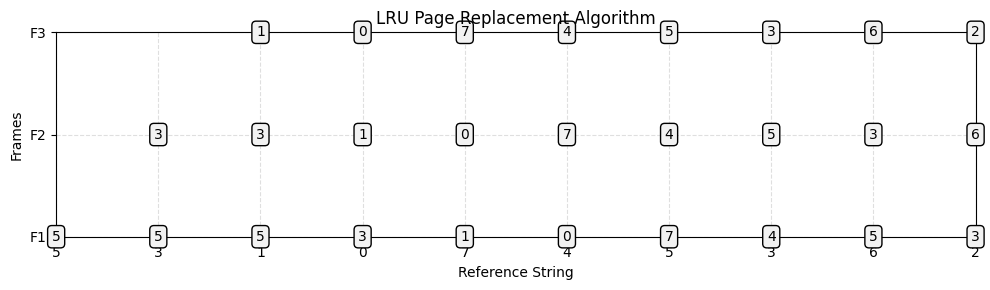


Page Hits: 0
Page Faults: 10

Choose Algorithm
1. FIFO
2. LRU
3. Optimal
4. Exit


KeyboardInterrupt: Interrupted by user

In [ ]:
import matplotlib.pyplot as plt
import random

def draw_frames(history, reference_string, frames_count, title):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, frames_count))

    # for row in range(frames_count):
    #     for col, frames in enumerate(history):
    #         value = frames[row] if row < len(frames) else ""
    #         plt.text(col, row, str(value),
    #                  ha='center', va='center',
    #                  bbox=dict(boxstyle="round,pad=0.3",
    #                            edgecolor="black",
    #                            facecolor="#f2f2f2"))

    for row in range(frames_count):
        col = 0
        for frames in history:
            if row < len(frames):
                value = frames[row]
            else:
                value = ""

            plt.text(col, row, str(value),
                    ha='center', va='center',
                    bbox=dict(boxstyle="round,pad=0.3",
                              edgecolor="black",
                              facecolor="#f2f2f2"))
            col += 1

    plt.xticks(range(len(reference_string)), reference_string)
    plt.yticks(range(frames_count), [f"F{i+1}" for i in range(frames_count)])

    plt.title(title)
    plt.xlabel("Reference String")
    plt.ylabel("Frames")

    plt.grid(True, linestyle='--', alpha=0.4)


    plt.tight_layout()
    plt.show()

# FIFO Algorithm

def fifo(reference_string, frames_count):
    frames, history = [], []
    pointer, hits, faults = 0, 0, 0

    for page in reference_string:
        if page in frames:
            hits += 1
        else:
            faults += 1
            if len(frames) < frames_count:
                frames.append(page)
            else:
                frames[pointer] = page
                pointer = (pointer + 1) % frames_count
        history.append(frames.copy())

    return history, hits, faults

# LRU Algorithm

def lru(reference_string, frames_count):
    frames, history = [], []
    hits, faults = 0, 0

    for page in reference_string:
        if page in frames:
            hits += 1
            frames.remove(page)
            frames.append(page)
        else:
            faults += 1
            if len(frames) < frames_count:
                frames.append(page)
            else:
                frames.pop(0)
                frames.append(page)
        history.append(frames.copy())

    return history, hits, faults


# Optimal Algorithm

def optimal(reference_string, frames_count):
    frames, history = [], []
    hits = faults = 0

    for i in range(len(reference_string)):
        page = reference_string[i]

        if page in frames:
            hits += 1
        else:
            faults += 1

            if len(frames) < frames_count:
                frames.append(page)
            else:
                future = reference_string[i+1:]

                farthest_index = -1
                pos = -1

                # Find page used farthest in future
                for j in range(len(frames)):
                    f = frames[j]

                    if f in future:
                        next_use = future.index(f)
                    else:
                        next_use = float('inf')

                    if next_use > farthest_index:
                        farthest_index = next_use
                        pos = j

                frames[pos] = page

        history.append(frames.copy())

    return history, hits, faults


def main():
    n = int(input("Enter number of pages in reference string: "))
    frames_count = int(input("Enter number of frames: "))

    reference_string = [random.randint(0, 9) for _ in range(n)]
    print("Generated Reference String:", reference_string)

    while True:
        print("\nChoose Algorithm")
        print("1. FIFO")
        print("2. LRU")
        print("3. Optimal")
        print("4. Exit")

        choice = int(input("Enter choice: "))

        if choice == 1:
            history, hits, faults = fifo(reference_string, frames_count)
            title = "FIFO Page Replacement Algorithm"
        elif choice == 2:
            history, hits, faults = lru(reference_string, frames_count)
            title = "LRU Page Replacement Algorithm"
        elif choice == 3:
            history, hits, faults = optimal(reference_string, frames_count)
            title = "Optimal Page Replacement Algorithm"
        elif choice == 4:
            print("Exiting program...")
            break
        else:
            print("Invalid choice")
            continue

        draw_frames(history, reference_string, frames_count, title)

        print("\nPage Hits:", hits)
        print("Page Faults:", faults)


if __name__ == "__main__":
    main()